# 🏏 IPL Data Scientist Hiring

<div style="background-color: #1e3a8a; color: white; padding: 20px; border-radius: 10px;">
<h2>Position: Senior Data Scientist - IPL Analytics Team</h2>

<p><b>Dataset:</b> Indian IPL Dataset 2008-2024</p>
<p><b>Submission:</b> Jupyter Notebook with code, visualizations, and insights</p>
</div>

## 📊 Background

The Indian Premier League (IPL) is seeking a talented Data Scientist to join our analytics team. Your role will involve analyzing match data, player performance, fan sentiment, and providing strategic insights to team management.

## 📁 Dataset Information

**Key Columns:**
- `id:` A unique identifier assigned to each IPL match.
- `season:` The year in which the IPL season took place.
- `city`: The city where the match was played.
- `date`: The date on which the match was held.
- `match_type`: Type of the match (e.g., League, Playoff, Final).
- `player_of_match`: The player who was awarded “Player of the Match” for their performance.
- `venue`: The stadium or ground where the match was played.
- `team1`: The first team listed in the fixture.
- `team2`: The second team listed in the fixture.
- `toss_winner`: The team that won the toss before the match began.
- `toss_decision`: The decision made by the toss-winning team—either to bat or to field first.
- `winner`: The team that won the match.
- `result`: The method of victory—either by runs, wickets, or other (e.g., tie, no result).
- `result_margin`: The margin by which the match was won (e.g., number of runs or wickets).
- `target_runs`: The number of runs set as a target for the chasing team.
- `target_overs`: The number of overs available to chase the target.
- `super_over`: Indicates whether the match was decided by a super over (‘Y’ for Yes, ‘N’ for No).
- `method`: The method used to decide the match result if it was interrupted (e.g., Duckworth–Lewis method).
- `umpire1`: Name of the first on-field umpire officiating the match.
- `umpire2`: Name of the second on-field umpire officiating the match.
---

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📝 Question 1: Data Preprocessing & Feature Engineering

### Task:
1. Load the IPL dataset and perform comprehensive EDA
2. Handle missing values appropriately with justification
3. Create these new features:(**These are examples you can create more along with this )**
   - `home_advantage`: Boolean indicating if team1 is playing in their home city(optional can be done with assumption)
   - venue_matches_team1_prior / venue_matches_team2_prior: number of matches the team has played at this same venue before the current match date
   - `match_importance`: Categorical (league/playoff/final) based on date and season
   - `toss_advantage`: Whether toss winner won the match
   - `season_phase`: Early/Mid/Late season

### Deliverables:
- Clean dataset with no missing values
- Visualization showing distribution of matches across venues
- Statistical summary of win percentages for toss winners

```python
# Your code here
```

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load IPL dataset
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("IPL_2008-2024.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Saving IPL_2008-2024.csv to IPL_2008-2024 (1).csv
Dataset Shape: (1095, 20)

Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [22]:
# BASIC DATASET INFORMATION

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nDataset Information:")
df.info()

Number of rows: 1095
Number of columns: 27

Column Names:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'team1_won', 'team2_won', 'toss_winner_won', 'team_matchup', 'margin_available', 'target_available', 'is_super_over']

Data Types:


,Data_Type
id,int64
season,int64
city,string[python]
date,datetime64[ns]
match_type,string[python]
player_of_match,string[python]
venue,string[python]
team1,string[python]
team2,string[python]
toss_winner,string[python]



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1095 entries, 0 to 1094
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                1095 non-null   int64         
 1   season            1095 non-null   int64         
 2   city              1044 non-null   string        
 3   date              1095 non-null   datetime64[ns]
 4   match_type        1095 non-null   string        
 5   player_of_match   1090 non-null   string        
 6   venue             1095 non-null   string        
 7   team1             1095 non-null   string        
 8   team2             1095 non-null   string        
 9   toss_winner       1095 non-null   string        
 10  toss_decision     1095 non-null   string        
 11  winner            1090 non-null   string        
 12  result            1095 non-null   string        
 13  result_margin     1076 non-null   float64       
 14  target_

In [21]:
# Missing Values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
method,1074,98.08
city,51,4.66
result_margin,19,1.74
team1_won,5,0.46
winner,5,0.46
toss_winner_won,5,0.46
team2_won,5,0.46
player_of_match,5,0.46
target_overs,3,0.27
target_runs,3,0.27


In [23]:
# DUPLICATE CHECK
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate match IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate match IDs: 0


,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


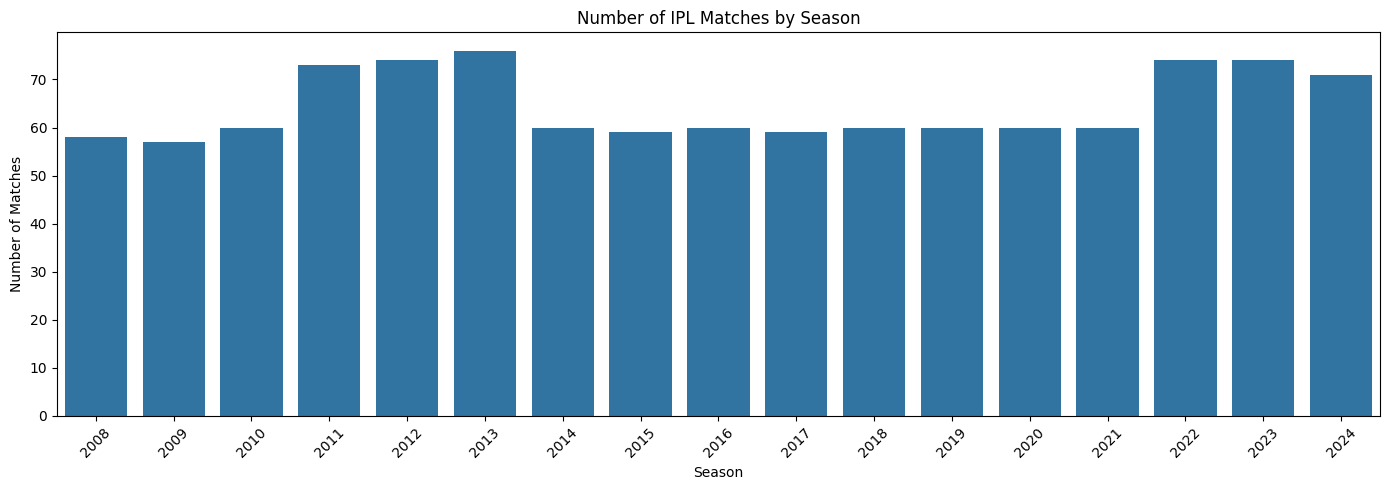

In [25]:
# Season Distribution - MATCHES BY SEASON
season_counts = (
    df.groupby("season")
      .size()
      .reset_index(name="matches")
)

display(season_counts)

plt.figure(figsize=(14, 5))

sns.barplot(
    data=season_counts,
    x="season",
    y="matches"
)

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Data Type Convertions
# Convert date
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Numeric columns
numeric_columns = [
    "season",
    "result_margin",
    "target_runs",
    "target_overs"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# String/categorical columns
categorical_columns = [
    "city",
    "match_type",
    "player_of_match",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner",
    "result",
    "super_over",
    "method",
    "umpire1",
    "umpire2"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

In [27]:
# Missing Value Treatment
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
)

,missing_count,missing_percentage
city,51,4.66
player_of_match,5,0.46
winner,5,0.46
result_margin,19,1.74
target_runs,3,0.27
target_overs,3,0.27
method,1074,98.08
team1_won,5,0.46
team2_won,5,0.46
toss_winner_won,5,0.46


In [29]:
# HANDLE MISSING VALUES

# Categorical columns
categorical_fill = [
    "city",
    "player_of_match",
    "result",
    "method",
    "super_over",
    "umpire1",
    "umpire2"
]

for col in categorical_fill:
    df[col] = df[col].fillna("Not Available")


# Numeric columns where missing means
# the metric was not applicable
df["result_margin"] = df["result_margin"].fillna(0)
df["target_runs"] = df["target_runs"].fillna(0)
df["target_overs"] = df["target_overs"].fillna(0)

# Preserve the fact that these matches had no recorded winner
df["winner_available"] = df["winner"].notna()

df["winner"] = df["winner"].fillna("No Winner")

In [30]:
# Feature Engineering
# TOSS ADVANTAGE
df["toss_advantage"] = np.where(
    (df["toss_winner"] == df["winner"]) &
    (df["winner"] != "No Winner"),
    True,
    False
)
df["toss_advantage"].value_counts()


,count
toss_advantage,
True,554
False,541


This represents:
True → Toss winner subsequently won the match
False → Toss winner did not win the match

In [32]:
# SEASON PHASE

df = df.sort_values(
    ["season", "date"]
).reset_index(drop=True)

df["season_match_number"] = (
    df.groupby("season")
      .cumcount() + 1
)

df["season_total_matches"] = (
    df.groupby("season")["id"]
      .transform("count")
)

df["season_progress"] = (
    df["season_match_number"] /
    df["season_total_matches"]
)

df["season_phase"] = pd.cut(
    df["season_progress"],
    bins=[0, 1/3, 2/3, 1],
    labels=["Early", "Mid", "Late"],
    include_lowest=True
)

display(
    df[
        [
            "season",
            "date",
            "season_match_number",
            "season_progress",
            "season_phase"
        ]
    ].head(20)
)

,season,date,season_match_number,season_progress,season_phase
0,2008,2008-04-18,1,0.017241,Early
1,2008,2008-04-19,2,0.034483,Early
2,2008,2008-04-19,3,0.051724,Early
3,2008,2008-04-20,4,0.068966,Early
4,2008,2008-04-20,5,0.086207,Early
5,2008,2008-04-21,6,0.103448,Early
6,2008,2008-04-22,7,0.120690,Early
7,2008,2008-04-23,8,0.137931,Early
8,2008,2008-04-24,9,0.155172,Early
9,2008,2008-04-25,10,0.172414,Early


In [42]:
# venue_matches_team1_prior - PRIOR VENUE EXPERIENCE

df = df.sort_values("date").reset_index(drop=True)

team_venue_history = {}

team1_prior = []
team2_prior = []

for _, row in df.iterrows():

    venue = row["venue"]
    team1 = row["team1"]
    team2 = row["team2"]

    key1 = (team1, venue)
    key2 = (team2, venue)

    team1_prior.append(
        team_venue_history.get(key1, 0)
    )

    team2_prior.append(
        team_venue_history.get(key2, 0)
    )

    # Update history AFTER calculating prior experience
    team_venue_history[key1] = (
        team_venue_history.get(key1, 0) + 1
    )

    team_venue_history[key2] = (
        team_venue_history.get(key2, 0) + 1
    )

df["venue_matches_team1_prior"] = team1_prior
df["venue_matches_team2_prior"] = team2_prior

# Check Result


In [37]:
# HOME ADVANTAGE
home_city_mapping = {
    "Mumbai Indians": "Mumbai",
    "Chennai Super Kings": "Chennai",
    "Royal Challengers Bengaluru": "Bengaluru",
    "Royal Challengers Bangalore": "Bangalore",
    "Kolkata Knight Riders": "Kolkata",
    "Delhi Capitals": "Delhi",
    "Delhi Daredevils": "Delhi",
    "Punjab Kings": "Mohali",
    "Kings XI Punjab": "Mohali",
    "Rajasthan Royals": "Jaipur",
    "Sunrisers Hyderabad": "Hyderabad",
    "Deccan Chargers": "Hyderabad",
    "Gujarat Titans": "Ahmedabad",
    "Lucknow Super Giants": "Lucknow",
    "Rising Pune Supergiant": "Pune",
    "Rising Pune Supergiants": "Pune",
    "Pune Warriors": "Pune"
}

df["team1_home_city"] = df["team1"].map(
    home_city_mapping
)

df["team2_home_city"] = df["team2"].map(
    home_city_mapping
)

df["home_advantage"] = (
    (df["city"] == df["team1_home_city"]) |
    (df["city"] == df["team2_home_city"])
)
# For the feature specifically requested as "team1 is playing in their home city"
df["team1_home_advantage"] = (
    df["city"] == df["team1_home_city"]
)

In [41]:
# Match Importance
df["match_type"].value_counts(dropna=False)

def classify_match_importance(row):

    match_type = str(row["match_type"]).lower()

    if "final" in match_type:
        return "Final"

    elif any(
        x in match_type
        for x in ["qualifier", "eliminator", "playoff"]
    ):
        return "Playoff"

    else:
        return "League"


df["match_importance"] = df.apply(
    classify_match_importance,
    axis=1
)

# Check
display(
    df["match_importance"]
    .value_counts()
    .to_frame("matches")
)

,matches
match_importance,
League,1030
Playoff,39
Final,26


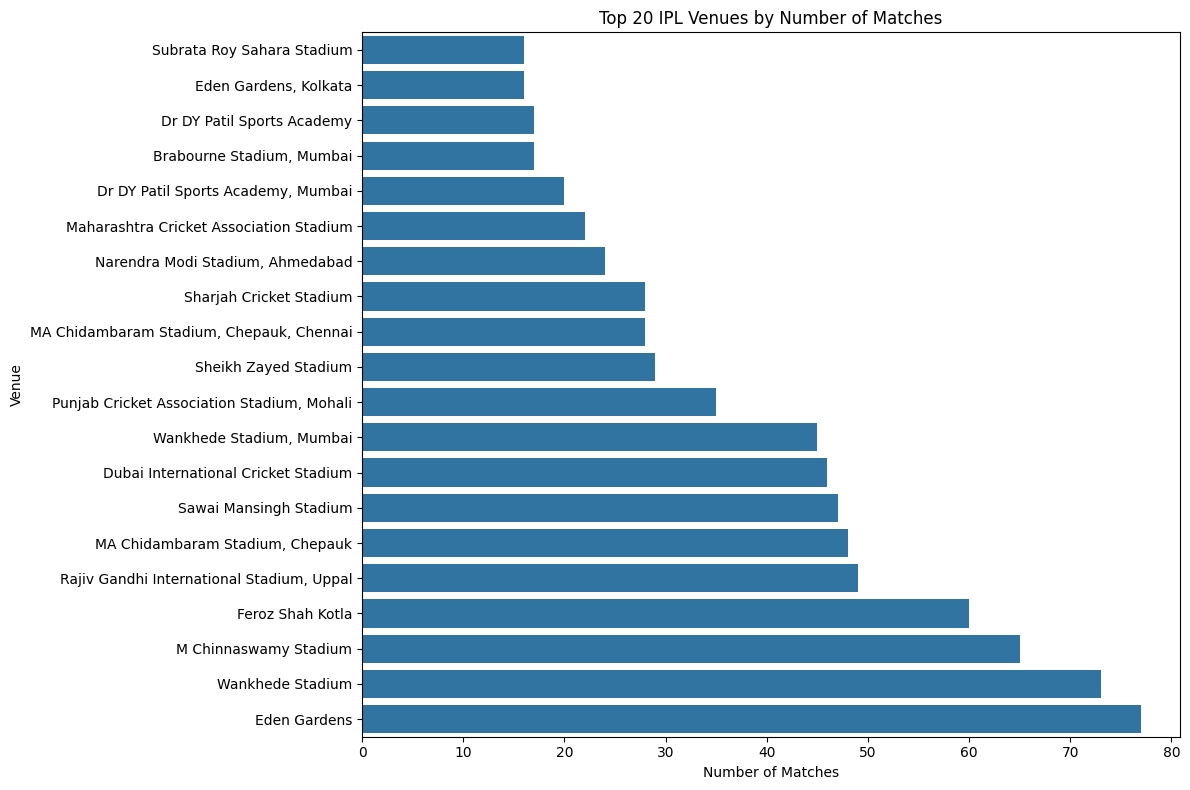

In [44]:
# Visualizations - MATCH DISTRIBUTION BY VENUE

top_venues = (
    df["venue"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_venues.values,
    y=top_venues.index
)

plt.title("Top 20 IPL Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

In [45]:
# Required Statistical Summary – Toss Winner
# TOSS WINNER STATISTICS

valid_toss_matches = df[
    (df["toss_winner"] != "No Winner") &
    (df["winner"] != "No Winner")
].copy()

valid_toss_matches["toss_winner_won_match"] = (
    valid_toss_matches["toss_winner"] ==
    valid_toss_matches["winner"]
)

toss_summary = pd.DataFrame({
    "Total Matches": [
        len(valid_toss_matches)
    ],

    "Toss Winner Won": [
        valid_toss_matches[
            "toss_winner_won_match"
        ].sum()
    ],

    "Toss Winner Lost": [
        (~valid_toss_matches[
            "toss_winner_won_match"
        ]).sum()
    ],

    "Toss Winner Win %": [
        valid_toss_matches[
            "toss_winner_won_match"
        ].mean() * 100
    ]
})

toss_summary["Toss Winner Win %"] = (
    toss_summary["Toss Winner Win %"].round(2)
)

display(toss_summary)

,Total Matches,Toss Winner Won,Toss Winner Lost,Toss Winner Win %
0,1090,554,536,50.83


,season,matches,toss_winner_wins,toss_winner_win_pct
0,2008,58,28,48.28
1,2009,57,33,57.89
2,2010,60,31,51.67
3,2011,72,38,52.78
4,2012,74,33,44.59
5,2013,76,36,47.37
6,2014,60,30,50.0
7,2015,57,28,49.12
8,2016,60,34,56.67
9,2017,59,34,57.63


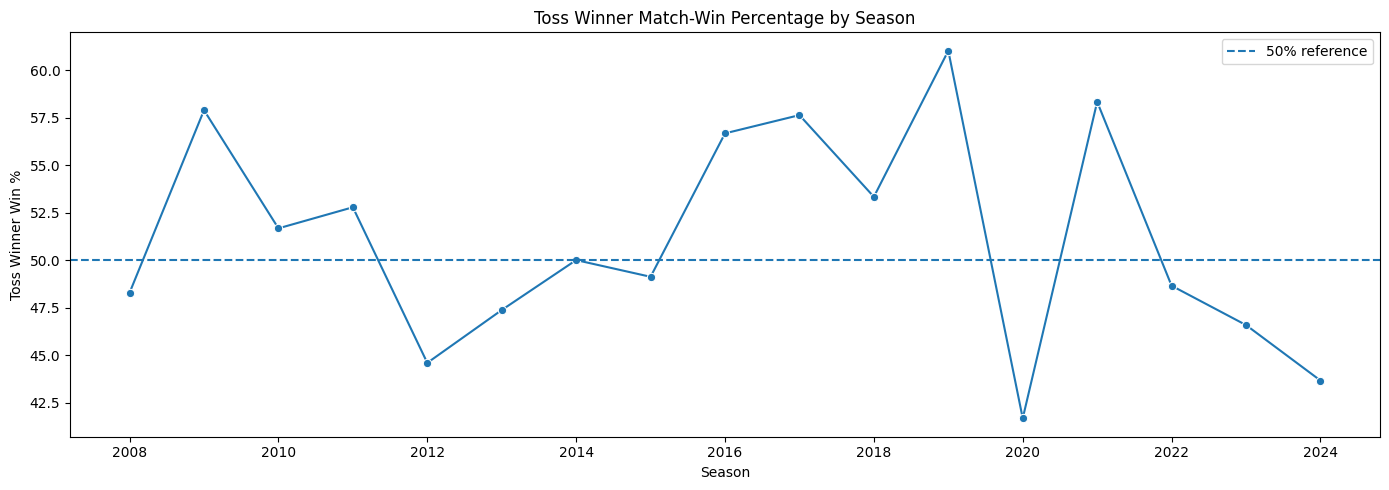

In [47]:
toss_by_season = (
    valid_toss_matches
    .groupby("season")
    .agg(
        matches=("id", "count"),
        toss_winner_wins=(
            "toss_winner_won_match",
            "sum"
        ),
        toss_winner_win_pct=(
            "toss_winner_won_match",
            "mean"
        )
    )
    .reset_index()
)

toss_by_season["toss_winner_win_pct"] = (
    toss_by_season["toss_winner_win_pct"] * 100
).round(2)

display(toss_by_season)
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=toss_by_season,
    x="season",
    y="toss_winner_win_pct",
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% reference"
)

plt.title(
    "Toss Winner Match-Win Percentage by Season"
)

plt.xlabel("Season")
plt.ylabel("Toss Winner Win %")

plt.legend()
plt.tight_layout()
plt.show()

In [56]:
df["winner"] = df["winner"].fillna("No Winner")
print(df["winner"].isna().sum())

for col in df.columns:
    missing = df[col].isna().sum()

    if missing > 0:
        print(f"{col}: {missing}")



0
team1_won: 5
team2_won: 5
toss_winner_won: 5
team1_home_city: 23
team2_home_city: 21
home_advantage: 25
team1_home_advantage: 23


In [64]:
boolean_columns = df.select_dtypes(
    include=["bool"]
).columns

for col in boolean_columns:
    df[col] = df[col].fillna(False)

numeric_columns = df.select_dtypes(
    include=["number"]
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(0)

# Convert categorical columns to string first
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_columns:
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("Not Available")

In [67]:
#FINAL DATA QUALITY CHECK

print("Final Dataset Shape:", df.shape)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Match IDs:",
    df["id"].duplicated().sum()
)

# Show any remaining missing values
remaining_missing = (
    df.isnull()
      .sum()
      .to_frame("Missing_Count")
      .query("Missing_Count > 0")
)

display(remaining_missing)

Final Dataset Shape: (1095, 40)
Total Missing Values: 0
Duplicate Rows: 0
Duplicate Match IDs: 0


,Missing_Count


## 📝 Question 2: Team Performance Clustering

### Task:
Perform **clustering analysis** to group teams based on their performance metrics:

1. Create team-level features:
   - Win percentage
   - Average victory margin (runs/wickets)
   - Toss win to match win ratio
   - Home vs away performance(optional based on assumption)
   - Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.

2. Apply K-means clustering to identify team categories
3. Use elbow method to determine optimal clusters
4. Visualize clusters using PCA for dimensionality reduction(optional)

### Expected Output:
- Team clusters with labels (e.g., "Dominant Teams", "Inconsistent Performers")
- Cluster characteristics interpretation

```python
# Your code here
```

## 📝 Question 3: Match Outcome Prediction - Logistic Regression

### Task:
Build a **Logistic Regression** model to predict match winners:

1. Feature engineering:
   - One-hot encode categorical variables
   - Create interaction features (team × venue, team × toss)
   - Scale numerical features

2. Handle class imbalance using **SMOTE** if necessary

3. Apply **L1 and L2 regularization**:
   - Compare model performance
   - Identify most important features

4. Evaluate using:
   - ROC-AUC score
   - Precision-Recall curve
   - Feature importance plot

```python
# Your code here
```

## 📝 Question 4: Performance Trend Analysis

### Task:
Use **Linear Regression** to analyze performance trends:

1. Track team performance over seasons:
   - Create yearly win percentage for each team
   - Fit linear regression to identify improving/declining teams

2. Predict next season performance

3. Identify factors affecting performance trends: (For example)
   - Toss luck: per‑season difference between toss win% and match win%.
   - Venue familiarity exposure: share of matches at team’s top‑3 venues.
   - Opponent strength index: seasonal average win% of opponents.

### Visualization:
- Time series plot with regression lines for top 5 teams

```python
# Your code here
```

## 📝 Question 5: Player of Match Prediction - KNN

### Task:
Use **K-Nearest Neighbors (KNN)** to predict potential 'Player of Match':

1. Build match‑context features:

Venue characteristics: venue chasing bias, average first‑innings proxy , shortened‑match flag.

Team strengths: recent win% (rolling window or per‑season).

Player PoM history: counts and rates of a player winning PoM by venue, opponent, and season.

Find similar historical matches (KNN on the context features).

Predict top‑k candidate PoM names (rank by neighbor votes or PoM prior × similarity).

Tune k via cross‑validation.

```python
# Your code here
```

## 📝 Question 6: Toss Decision Strategy - Decision Tree

### Task:
Build a **Decision Tree** to recommend toss decisions:

1. Create a model to predict optimal toss decision (bat/field) based on:
   - Venue history
   - Weather conditions (create synthetic if not available)
   - Team strengths
   - Match importance

2. Visualize the decision tree (max_depth=5)

3. Extract decision rules in plain English

4. Calculate feature importance

### Business Application:
"Provide captains with data-driven toss decision recommendations"

```python
# Your code here
```

## 📝 Question 7: Advanced Match Prediction - Ensemble Methods

### Task:
Compare **Bagging** and **Boosting** for match outcome prediction:

1. Implement Random Forest (Bagging):
   - Use all available features
   - Tune hyperparameters
   - Feature importance analysis

2. Implement XGBoost/AdaBoost (Boosting):
   - Compare with Random Forest
   - Analyze prediction confidence

3. Create an ensemble combining both approaches

4. Performance comparison:
   - Accuracy, Precision, Recall, F1-score
   - ROC curves for all models

```python
# Your code here
```

# FEATURES mentioned in questions are high level example. You can create more features to make your model robust

## 📤 Submission Guidelines

1. Submit a single Jupyter notebook with all solutions
2. Include markdown cells explaining your approach
3. Ensure all code is reproducible
4. Add a summary section with key findings
5. List any assumptions made

## 💡 Tips
- Focus on practical insights over complex models
- Validate all findings with appropriate metrics
- Consider real-world IPL scenarios in your analysis
- Document any data quality issues encountered

---

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; text-align: center;">
<h3>🏆 Good Luck!</h3>
<p>May the best Data Scientist win!</p>
</div>